In [4]:
import nltk
from collections import defaultdict
import pandas as pd

In [1]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-gmq")
model = AutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-en-gmq").to(2)

In [15]:
prefix = ">>nob<<"

dfs = {}

def dataprep(_split):
    _df = pd.read_csv(f"mosaic_{_split}.csv")

    _instr = _df["instruction"].tolist()
    _res = _df["response"].tolist()

    chunked_instr = {}
    chunked_res = {}

    max_len = 256

    for i, (instr, res) in enumerate(zip(_instr, _res)):
        # 2. create chunks of up to 512 tokens, based on sentence segmentation from nltk
        instr_sents = nltk.sent_tokenize(instr, language="english")
        res_sents = nltk.sent_tokenize(res, language="english")
        # if there's math and latex-style formulas, ignore translation and just use the original
        # if "$" in instr:
        #     chunked_instr[i] = instr
        # elif "$" in res:
        #     chunked_res[i] = res
        if "$" in instr or "$" in res:
            continue
        prefixed_instr = [f"{prefix} {s}" for s in instr_sents]
        prefixed_res = [f"{prefix} {s}" for s in res_sents]
        # check tokenized input_ids length:
        # if too long, chunk it up
        instr_inputs = tokenizer(prefixed_instr, return_tensors="pt", padding=True, truncation=True)["input_ids"]
        res_inputs = tokenizer(prefixed_res, return_tensors="pt", padding=True, truncation=True)["input_ids"]
        
        for input_id in instr_inputs:
            if len(input_id) > 512:
                continue
        for input_id in res_inputs:
            if len(input_id) > 512:
                continue

        if len(prefixed_instr) != len(instr_sents):
            # skip incompatible examples
            continue

        chunked_instr[i] = prefixed_instr
        chunked_res[i] = prefixed_res
            
    # convert the dict of index -> list of sents
    # to a 1-D mapping of index, sent
    instr_map = []
    for i, sents in chunked_instr.items():
        if type(sents) == str:
            instr_map.append((i, sents))
        else:
            for s in sents:
                instr_map.append((i, s))
    res_map = []
    for i, sents in chunked_res.items():
        if type(sents) == str:
            res_map.append((i, sents))
        else:
            for s in sents:
                res_map.append((i, s))

    return instr_map, res_map

instr_map, res_map = dataprep("train")

In [18]:
def map_and_index(_map):
    _index_map = [(sent_num, idx) for sent_num, (idx, _) in enumerate(_map)]
    _sentences = [sent for _, sent in _map]
    return _index_map, _sentences

instr_index_map, instr_sentences = map_and_index(instr_map)
res_index_map, res_sentences = map_and_index(res_map)
print(instr_index_map[:10])
print(instr_sentences[:10])

[(0, 0), (1, 2), (2, 3), (3, 4), (4, 4), (5, 4), (6, 5), (7, 7), (8, 7), (9, 7)]
['>>nob<< What are different types of grass?', '>>nob<< How can I cook food while camping?', '>>nob<< What are some fun scenarios my kids can play with their Barbies?', '>>nob<< How many titles have Liverpool won?', '>>nob<< Domestically, the club has won 19 League titles, eight FA Cups, a record nine League Cups and 16 FA Community Shields.', '>>nob<< In international competitions, the club has won six European Cups, three UEFA Cups, four UEFA Super Cups—all English records—and one FIFA Club World Cup.', '>>nob<< Is it hard to become an ophthalmologist ?', ">>nob<< Was She Couldn't Say No movie re-released?", ">>nob<< She Couldn't Say No is a 1954 American rural comedy film starring Robert Mitchum, Jean Simmons and Arthur Hunnicutt.", '>>nob<< The last film in the long directing career of Lloyd Bacon, it was later re-released as Beautiful but Dangerous']


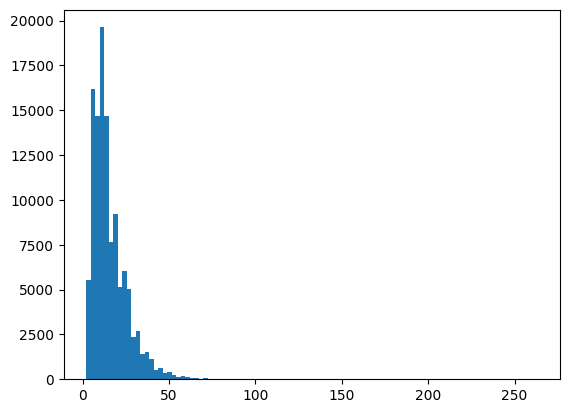

In [19]:
# plot lengths of instr_sentences
import matplotlib.pyplot as plt
plt.hist([len(s.split()) for s in instr_sentences], bins=100);

In [46]:
from tqdm import tqdm

DEVICE = 2
def translate_batch(sentences, batch_size=128):
    num_batches = (len(sentences) + batch_size - 1) // batch_size
    translated_sentences = []
    
    for i in tqdm(range(num_batches)):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, len(sentences))
        batch_sentences = sentences[start_idx:end_idx]
        
        translated = model.generate(**tokenizer(batch_sentences, return_tensors="pt", padding=True).to(DEVICE))
        for t in translated:
            translated_sentences.append(tokenizer.decode(t, skip_special_tokens=True))
    
    return translated_sentences

translated_instr = translate_batch(instr_sentences)
translated_resp = translate_batch(res_sentences)

  1%|          | 8/907 [00:33<56:25,  3.77s/it]  